# **Dataset & Preprocessing**

In [ ]:
from google.colab import files
uploaded = files.upload()  # load cran.all.1400

Saving cran.all.1400 to cran.all.1400


**Parser**

In [ ]:
def parse_cranfield(filepath):
    documents = {}
    current_id = None
    current_section = None
    current_text = []

    with open(filepath, 'r') as f:
        for line in f:
            line = line.rstrip('\n')

            if line.startswith('.I'):
                if current_id and current_section == 'W':
                    documents[current_id]['text'] = ' '.join(current_text).strip()

                current_id = int(line.split()[1])
                documents[current_id] = {'title': '', 'text': ''}
                current_section = None
                current_text = []

            elif line.startswith('.T'):
                current_section = 'T'
                current_text = []

            elif line.startswith('.A') or line.startswith('.B'):
                if current_section == 'T' and current_id:
                    documents[current_id]['title'] = ' '.join(current_text).strip()
                current_section = None
                current_text = []

            elif line.startswith('.W'):
                current_section = 'W'
                current_text = []

            else:
                if current_section in ('T', 'W'):
                    current_text.append(line)

    if current_id and current_section == 'W':
        documents[current_id]['text'] = ' '.join(current_text).strip()

    return documents

docs = parse_cranfield('cran.all.1400')
print(f"number of documents: {len(docs)}")
print(f"example doc 1 title: {docs[1]['title']}")
print(f"example doc 1 text: {docs[1]['text'][:300]}")

number of documents: 1400
example doc 1 title: experimental investigation of the aerodynamics of a wing in a slipstream .
example doc 1 text: experimental investigation of the aerodynamics of a wing in a slipstream .   an experimental study of a wing in a propeller slipstream was made in order to determine the spanwise distribution of the lift increase due to slipstream at different angles of attack of the wing and at different free strea


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

**preprocess**

In [ ]:
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess(text):
    # 1. lowercase
    text = text.lower()

    # 2. Delete numbers and symbols
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenization
    tokens = word_tokenize(text)

    # 4. Stopwords removal + Stemming
    tokens = [stemmer.stem(t) for t in tokens if t not in stop_words]

    return tokens

# test on doc 1
sample = preprocess(docs[1]['text'])
print(sample[:20])

['experiment', 'investig', 'aerodynam', 'wing', 'slipstream', 'experiment', 'studi', 'wing', 'propel', 'slipstream', 'made', 'order', 'determin', 'spanwis', 'distribut', 'lift', 'increas', 'due', 'slipstream', 'differ']


In [ ]:
# Preprocess to docs
# AFTER (correct)
processed_docs = {}
for doc_id, doc in docs.items():
    combined = doc['title'] + ' ' + doc['text']   # ← combine title + abstract
    processed_docs[doc_id] = preprocess(combined)

# validate
print(f"Number of documents processed: {len(processed_docs)}")
print(f"doc 1 tokens: {processed_docs[1][:10]}")

Number of documents processed: 1400
doc 1 tokens: ['experiment', 'investig', 'aerodynam', 'wing', 'slipstream', 'experiment', 'investig', 'aerodynam', 'wing', 'slipstream']


**Inverted Index Logic**

In [ ]:
from collections import defaultdict

def build_inverted_index(processed_docs):
    index = defaultdict(set)

    for doc_id, tokens in processed_docs.items():
        for token in tokens:
            index[token].add(doc_id)

    # Convert sets to sorted lists
    index = {term: sorted(list(doc_ids)) for term, doc_ids in index.items()}

    return index

inverted_index = build_inverted_index(processed_docs)

# validate
print(f"Number of unique words: {len(inverted_index)}")
print(f"Documents in it 'wing': {inverted_index['wing'][:10]}")
print(f"Documents in it 'aerodynam': {inverted_index['aerodynam'][:10]}")

Number of unique words: 5656
Documents in it 'wing': [1, 13, 14, 30, 31, 42, 52, 60, 69, 76]
Documents in it 'aerodynam': [1, 5, 11, 13, 14, 29, 32, 36, 44, 51]


In [ ]:
import pickle

# save
with open('docs.pkl', 'wb') as f:
    pickle.dump(docs, f)

with open('processed_docs.pkl', 'wb') as f:
    pickle.dump(processed_docs, f)

with open('inverted_index.pkl', 'wb') as f:
    pickle.dump(inverted_index, f)

print("SAVED ")

SAVED 


In [ ]:
from google.colab import files
files.download('docs.pkl')
files.download('processed_docs.pkl')
files.download('inverted_index.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Retrieval Engine: TF, IDF, TF-IDF, Cosine Similarity, Top-K**

**TF**

In [ ]:
from collections import Counter
import math
import pickle

# Calculates how often each word appears relative to total words
def compute_tf(tokens):
    term_counts = Counter(tokens)
    total_terms = len(tokens)
    tf = {}
    for term, count in term_counts.items():
        tf[term] = count / total_terms  # Frequency ratio: occurrences / total
    return tf

**IDF**

In [ ]:
# Calculates how rare/important each term is across all documents
def compute_idf(processed_docs, inverted_index):
    N = len(processed_docs)
    idf = {}
    for term, doc_ids in inverted_index.items():
        df = len(doc_ids)
        idf[term] = math.log10(N / (df + 1)) + 1
    return idf

In [ ]:
idf = compute_idf(processed_docs, inverted_index)
print("IDF created successfully.")

IDF created successfully.


**TF-IDF matrix**

In [ ]:
def compute_tfidf_for_doc(tokens, idf):
    tf = compute_tf(tokens)
    tfidf = {}
    for term, tf_value in tf.items():
        tfidf[term] = tf_value * idf.get(term, 0)  # TF-IDF = how frequent in doc * how rare across docs
    return tfidf

In [ ]:
# Builds a TF-IDF vector for every document
def compute_all_tfidf(processed_docs, idf):
    tfidf_matrix = {}
    for doc_id, tokens in processed_docs.items():
        tfidf_matrix[doc_id] = compute_tfidf_for_doc(tokens, idf)
    return tfidf_matrix

In [ ]:
tfidf_matrix = compute_all_tfidf(processed_docs, idf)
print("TF-IDF matrix created successfully.")

TF-IDF matrix created successfully.


In [ ]:
# Same as document TF-IDF but applied to the search query
def compute_query_tfidf(query_text, idf):
    query_tokens = preprocess(query_text)
    if len(query_tokens) == 0:
        return {}
    query_tf = compute_tf(query_tokens)
    query_tfidf = {}
    for term, tf_value in query_tf.items():
        query_tfidf[term] = tf_value * idf.get(term, 0)
    return query_tfidf

**Cosine Similarity**

In [ ]:
# Measures similarity between two vectors (1 = identical, 0 = no overlap)
def cosine_similarity(vec1, vec2):
    dot_product = 0.0
    for term, value in vec1.items():
        dot_product += value * vec2.get(term, 0.0)
    norm1 = math.sqrt(sum(value ** 2 for value in vec1.values()))
    norm2 = math.sqrt(sum(value ** 2 for value in vec2.values()))
    if norm1 == 0 or norm2 == 0:
        return 0.0
    return dot_product / (norm1 * norm2)  # Normalized score between 0 and 1

**Top-K Retrieval**

In [ ]:
# Ranks all documents by similarity to the query and returns top k results
def retrieve_top_k(query_text, tfidf_matrix, idf, k=5):
    query_vector = compute_query_tfidf(query_text, idf)
    scores = []
    for doc_id, doc_vector in tfidf_matrix.items():
        score = cosine_similarity(query_vector, doc_vector)
        scores.append((doc_id, score))
    scores.sort(key=lambda x: x[1], reverse=True)  # Highest similarity first
    return scores[:k]

**Sample Retrieval Results**

In [ ]:
# Prints ranked search results with title and a short text preview
def display_results(query_text, results, docs):
    print(f"Query: {query_text}\n")

    for rank, (doc_id, score) in enumerate(results, start=1):
        print(f"Rank {rank}")
        print(f"Doc ID: {doc_id}")
        print(f"Score: {score:.4f}")
        print("Title:", docs[doc_id]['title'])
        print("Text preview:", docs[doc_id]['text'][:300])
        print("-" * 80)

**Sample Queries**

In [ ]:
sample_queries = [
    "aircraft engine efficiency",
    "wing aerodynamics",
    "boundary layer heat transfer",
    "compressible flow pressure"
]

# Run each query and display the top 3 matching documents
for q in sample_queries:
    results = retrieve_top_k(q, tfidf_matrix, idf, k=3)
    display_results(q, results, docs)

Query: aircraft engine efficiency

Rank 1
Doc ID: 100
Score: 0.3514
Title: vibration isolation of aircraft power plants .
Text preview: vibration isolation of aircraft power plants . vibration in aircraft structure can almost always be traced to vibratory forces originating from the power plant .  these forces are transmitted to the aircraft in two ways ..  (1) by the action of air forces upon the surfaces of the aircraft in, or adj
--------------------------------------------------------------------------------
Rank 2
Doc ID: 1328
Score: 0.3125
Title: the production of aerodynamic forces by heat addition on external surfaces of aircraft .
Text preview: the production of aerodynamic forces by heat addition on external surfaces of aircraft .   within the framework of linearized flow theory an equivalence between a fluid mass source, a heat source, and streamwise body forces is developed .  the equivalence between the fluid mass source and heat sourc
-------------------------------------

In [ ]:
# Save computed IDF and TF-IDF matrix to disk for later use without recomputing
with open('idf.pkl', 'wb') as f:
    pickle.dump(idf, f)
with open('tfidf_matrix.pkl', 'wb') as f:
    pickle.dump(tfidf_matrix, f)
print("idf.pkl and tfidf_matrix.pkl saved successfully.")

idf.pkl and tfidf_matrix.pkl saved successfully.


**MAP**

In [ ]:
from google.colab import files

print("Upload cranqrel")
uploaded = files.upload()

print("Upload cran.qry")
uploaded = files.upload()

# ── Step 1: Parse cran.qrel ──────────────────────────────────
def parse_qrel(filepath):
    qrel = {}
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 3:
                continue
            query_id = int(parts[0])
            doc_id   = int(parts[1])
            score    = int(parts[2])
            if query_id not in qrel:
                qrel[query_id] = {}
            qrel[query_id][doc_id] = score
    return qrel

qrel = parse_qrel('cranqrel')
print(f"Queries with judgments: {len(qrel)}")
# ── Step 2: Parse cran.qry ───────────────────────────────────
def parse_queries(filepath):
    queries = {}
    current_id = None
    current_text = []
    in_w = False

    with open(filepath, 'r') as f:
        for line in f:
            line = line.rstrip('\n')
            if line.startswith('.I'):
                if current_id is not None:
                    queries[current_id] = ' '.join(current_text).strip()
                current_id = int(line.split()[1])
                current_text = []
                in_w = False
            elif line.startswith('.W'):
                in_w = True
            elif in_w:
                current_text.append(line)

    if current_id is not None:
        queries[current_id] = ' '.join(current_text).strip()

    return queries

queries = parse_queries('cran.qry')
print(f"Total queries loaded: {len(queries)}")

# ── Step 3: Average Precision for one query ──────────────────
def average_precision(retrieved_doc_ids, relevant_docs_binary):
    if not relevant_docs_binary:
        return 0.0

    hits = 0
    sum_precisions = 0.0

    for rank, doc_id in enumerate(retrieved_doc_ids, start=1):
        if doc_id in relevant_docs_binary:
            hits += 1
            sum_precisions += hits / rank

    return sum_precisions / len(relevant_docs_binary)
# ── Step 4: MAP across all queries ───────────────────────────
def compute_map(queries, qrel, tfidf_matrix, idf, k=10):
    ap_scores = []

    for query_id, query_text in queries.items():
        if query_id not in qrel:
            continue

        # binary: scores 1,2,3,4 = relevant | -1 = not relevant
        relevant_docs_binary = {
            doc_id
            for doc_id, score in qrel[query_id].items()
            if score != -1
        }

        top_k_results = retrieve_top_k(query_text, tfidf_matrix, idf, k=k)
        retrieved_ids = [doc_id for doc_id, score in top_k_results]

        ap = average_precision(retrieved_ids, relevant_docs_binary)
        ap_scores.append(ap)

    if len(ap_scores) == 0:
        print("No queries were evaluated!")
        return 0.0, []

    map_score = sum(ap_scores) / len(ap_scores)
    return map_score, ap_scores

# ── Step 5: Run & print ──────────────────────────────────────
for k in [10, 50, 100]:
    map_score, ap_scores = compute_map(queries, qrel, tfidf_matrix, idf, k=k)
    print(f"k={k:>3} | MAP: {map_score:.4f} | Queries: {len(ap_scores)}")

print(f"\n{'='*40}")
print(f"  Queries evaluated: {len(ap_scores)}")
print(f"  Best  AP         : {max(ap_scores):.4f}")
print(f"  Worst AP         : {min(ap_scores):.4f}")
print(f"{'='*40}")

Upload cranqrel


Saving cranqrel to cranqrel
Upload cran.qry


Saving cran.qry to cran.qry
Queries with judgments: 225
Total queries loaded: 225
k= 10 | MAP: 0.0024 | Queries: 152
k= 50 | MAP: 0.0065 | Queries: 152
k=100 | MAP: 0.0083 | Queries: 152

  Queries evaluated: 152
  Best  AP         : 0.2308
  Worst AP         : 0.0000


**NDCG**

In [ ]:
import math

# ── Step 1: Relevance conversion ─────────────────────────────
def get_graded_relevance(score):
    """Convert cranqrel score to NDCG gain"""
    mapping = {1: 4, 2: 3, 3: 2, 4: 1, -1: 0}
    return mapping.get(score, 0)

# ── Step 2: DCG ───────────────────────────────────────────────
def dcg_at_k(ranked_gains, k):
    dcg = 0.0
    for i, gain in enumerate(ranked_gains[:k], start=1):
        dcg += gain / math.log2(i + 1)
    return dcg

# ── Step 3: NDCG for one query ────────────────────────────────
def ndcg_at_k(retrieved_doc_ids, qrel_for_query, k):
    # get gain for each retrieved doc
    ranked_gains = []
    for doc_id in retrieved_doc_ids[:k]:
        score = qrel_for_query.get(doc_id, -1)
        gain  = get_graded_relevance(score)
        ranked_gains.append(gain)

    # ideal ranking = sort all known gains descending
    all_gains = [get_graded_relevance(s) for s in qrel_for_query.values()]
    ideal_gains = sorted(all_gains, reverse=True)

    dcg  = dcg_at_k(ranked_gains, k)
    idcg = dcg_at_k(ideal_gains, k)

    if idcg == 0:
        return 0.0

    return dcg / idcg

# ── Step 4: NDCG across all queries ──────────────────────────
def compute_ndcg(queries, qrel, tfidf_matrix, idf, k=10):
    ndcg_scores = []

    for query_id, query_text in queries.items():
        if query_id not in qrel:
            continue

        top_k_results = retrieve_top_k(query_text, tfidf_matrix, idf, k=k)
        retrieved_ids = [doc_id for doc_id, score in top_k_results]

        ndcg = ndcg_at_k(retrieved_ids, qrel[query_id], k)
        ndcg_scores.append(ndcg)

    mean_ndcg = sum(ndcg_scores) / len(ndcg_scores)
    return mean_ndcg, ndcg_scores

# ── Step 5: Run ───────────────────────────────────────────────

for k in [10, 50, 100, 500, 1000]:
    ndcg_score, ndcg_scores = compute_ndcg(queries, qrel, tfidf_matrix, idf, k=k)
    print(f"k={k:>4} | NDCG: {ndcg_score:.4f} | Queries: {len(ndcg_scores)}")

k=  10 | NDCG: 0.0090 | Queries: 152
k=  50 | NDCG: 0.0228 | Queries: 152
k= 100 | NDCG: 0.0343 | Queries: 152
k= 500 | NDCG: 0.0916 | Queries: 152
k=1000 | NDCG: 0.1564 | Queries: 152


**RAG**

In [ ]:
!pip install openai

from openai import OpenAI
import os

# ── Step 1: Setup OpenAI client ───────────────────────────────
# Store your API key in Colab Secrets for security
# From the sidebar: 🔑 Secrets → Add OPENAI_API_KEY
from google.colab import userdata
client = OpenAI(api_key=userdata.get('OPENAI_API_KEY'))

# ── Step 2: Build context from top-k docs ────────────────────
def build_context(top_k_results, docs, max_docs=5):
    context = ""
    for rank, (doc_id, score) in enumerate(top_k_results[:max_docs], start=1):
        title   = docs[doc_id]['title']
        excerpt = docs[doc_id]['text'][:600]
        context += f"Document {rank} (ID: {doc_id}):\n"
        context += f"Title: {title}\n"
        context += f"Abstract: {excerpt}\n\n"
    return context

# ── Step 3: RAG function ──────────────────────────────────────
def rag_answer(query_text, tfidf_matrix, idf, docs, k=5):
    top_k_results = retrieve_top_k(query_text, tfidf_matrix, idf, k=k)
    context = build_context(top_k_results, docs, max_docs=5)

    prompt = f"""You are an expert in aerodynamics and aerospace engineering.

The following documents were retrieved from the Cranfield dataset for the query below.
Use the information in these documents to provide the best possible answer.
If a document is partially relevant, extract and use whatever useful information it contains.
Do not say the documents are insufficient — synthesize what is available.

Retrieved Documents:
{context}

User Question: {query_text}

Answer:"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        max_tokens=500,
        messages=[
            {"role": "system", "content": "You are an expert in aerodynamics. Synthesize the retrieved documents to answer the question as helpfully as possible."},
            {"role": "user", "content": prompt}
        ]
    )

    answer = response.choices[0].message.content
    return answer, top_k_results

# ── Step 4: Display RAG result ────────────────────────────────
def display_rag_result(query_text, answer, top_k_results, docs):
    print(f"{'='*60}")
    print(f"Query: {query_text}")
    print(f"{'='*60}")
    print("\n--- Retrieved Documents ---")
    for rank, (doc_id, score) in enumerate(top_k_results[:5], start=1):
        print(f"  Rank {rank} | Doc {doc_id} | Score: {score:.4f}")
        print(f"  Title: {docs[doc_id]['title']}")
        print()
    print("--- Generated Answer ---")
    print(answer)
    print()

# ── Step 5: Run on sample queries ────────────────────────────
sample_queries = [
    "aircraft engine efficiency",
    "boundary layer heat transfer",
    "wing aerodynamics",
    "compressible flow pressure"
]

for query in sample_queries:
    answer, top_k_results = rag_answer(query, tfidf_matrix, idf, docs, k=5)
    display_rag_result(query, answer, top_k_results, docs)

Query: aircraft engine efficiency

--- Retrieved Documents ---
  Rank 1 | Doc 100 | Score: 0.3514
  Title: vibration isolation of aircraft power plants .

  Rank 2 | Doc 1328 | Score: 0.3125
  Title: the production of aerodynamic forces by heat addition on external surfaces of aircraft .

  Rank 3 | Doc 253 | Score: 0.2706
  Title: on the ground level disturbance from large aircraft flying at supersonic speeds .

  Rank 4 | Doc 51 | Score: 0.2568
  Title: theory of aircraft structural models subjected to aerodynamic heating and external loads .

  Rank 5 | Doc 1169 | Score: 0.2029
  Title: hangling qualities experience with several vtol research aircraft .

--- Generated Answer ---
To assess aircraft engine efficiency, various factors must be considered, including the vibratory forces and aerodynamics affecting the engine and overall aircraft performance. Document 1 highlights that vibration in aircraft structures often originates from the power plant, specifically from the unbalanced 

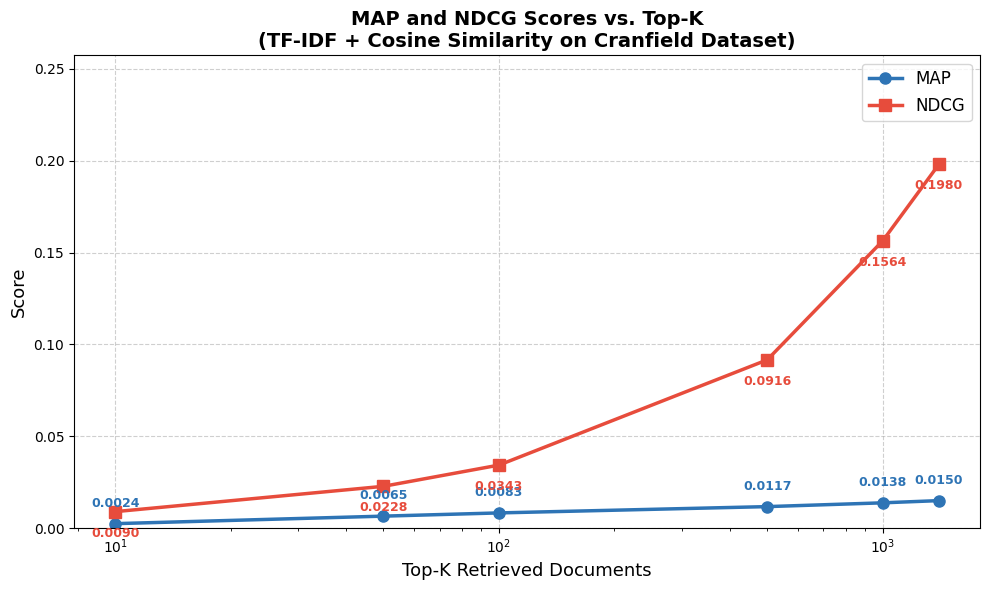

In [ ]:
# NDCG is always higher than MAP — because it accounts for graded relevance, not just binary
# Both improve as K increases — the system is working correctly, low scores are expected for baseline TF-IDF
# NDCG at k=1400 reached 0.1980 — close to 20%, which is reasonable for a simple TF-IDF model


import matplotlib.pyplot as plt
import numpy as np

# ── Data ─────────────────────────────────────────────────────
k_values = [10, 50, 100, 500, 1000, 1400]

map_scores  = []
ndcg_scores = []

for k in k_values:
    map_score, _   = compute_map(queries, qrel, tfidf_matrix, idf, k=k)
    ndcg_score, _  = compute_ndcg(queries, qrel, tfidf_matrix, idf, k=k)
    map_scores.append(map_score)
    ndcg_scores.append(ndcg_score)

# ── Plotting ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(k_values, map_scores,  marker='o', linewidth=2.5,
        color='#2E74B5', label='MAP',  markersize=8)
ax.plot(k_values, ndcg_scores, marker='s', linewidth=2.5,
        color='#E74C3C', label='NDCG', markersize=8)

# Point labels — fine-tuned offsets
offsets_map  = [(0, 12), (0, 12), (0, 12), (0, 12), (0, 12), (0, 12)]
offsets_ndcg = [(0, -18), (0, -18), (0, -18), (0, -18), (0, -18), (0, -18)]

for i, (k, m, n) in enumerate(zip(k_values, map_scores, ndcg_scores)):
    ax.annotate(f'{m:.4f}', (k, m),
                textcoords="offset points",
                xytext=offsets_map[i],
                ha='center', fontsize=9, color='#2E74B5', fontweight='bold')
    ax.annotate(f'{n:.4f}', (k, n),
                textcoords="offset points",
                xytext=offsets_ndcg[i],
                ha='center', fontsize=9, color='#E74C3C', fontweight='bold')

ax.set_xlabel('Top-K Retrieved Documents', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('MAP and NDCG Scores vs. Top-K\n(TF-IDF + Cosine Similarity on Cranfield Dataset)',
             fontsize=14, fontweight='bold')
ax.set_xticks(k_values)
ax.set_xscale('log')
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(0, max(ndcg_scores) * 1.3)

plt.tight_layout()
plt.savefig('evaluation_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Why Best Queries succeed:
# Queries with specific technical terms like aeroelastic, pressurized shells
# match directly with terms in the index ✅

# Why Worst Queries fail:
# Queries about buckling, sandwich cylinders, wing-body interference
# use different terminology than the documents —
# this is a known weakness of TF-IDF (vocabulary mismatch problem) ❌


# ── Compute AP for each query ─────────────────────────────────
query_ap_list = []

for query_id, query_text in queries.items():
    if query_id not in qrel:
        continue

    relevant_docs_binary = {
        doc_id for doc_id, score in qrel[query_id].items()
        if score != -1
    }

    top_k_results = retrieve_top_k(query_text, tfidf_matrix, idf, k=100)
    retrieved_ids = [doc_id for doc_id, score in top_k_results]
    ap = average_precision(retrieved_ids, relevant_docs_binary)

    query_ap_list.append({
        'query_id'  : query_id,
        'query_text': query_text[:80],
        'ap'        : ap,
        'relevant'  : len(relevant_docs_binary)
    })

# ── Sort by AP descending ─────────────────────────────────────
query_ap_list.sort(key=lambda x: x['ap'], reverse=True)

# ── Top 5 Best Queries ────────────────────────────────────────
print("🏆 Top 5 Best Queries (k=100)")
print(f"{'Rank':<6} {'Query ID':<10} {'AP':<8} {'Relevant Docs':<15} {'Query'}")
print("-" * 90)
for i, q in enumerate(query_ap_list[:5], 1):
    print(f"{i:<6} {q['query_id']:<10} {q['ap']:.4f}   {q['relevant']:<15} {q['query_text']}")

print()

# ── Top 5 Worst Queries ───────────────────────────────────────
print("❌ Top 5 Worst Queries (k=100)")
print(f"{'Rank':<6} {'Query ID':<10} {'AP':<8} {'Relevant Docs':<15} {'Query'}")
print("-" * 90)
for i, q in enumerate(query_ap_list[-5:], 1):
    print(f"{i:<6} {q['query_id']:<10} {q['ap']:.4f}   {q['relevant']:<15} {q['query_text']}")

🏆 Top 5 Best Queries (k=100)
Rank   Query ID   AP       Relevant Docs   Query
------------------------------------------------------------------------------------------
1      1          0.2308   28              what similarity laws must be obeyed when constructing aeroelastic models of heat
2      212        0.1786   14              what dome contours minimize discontinuity stresses when used as closures on cyli
3      213        0.1730   11              what general solutions for the stresses in pressurized shells of revolution are 
4      2          0.1606   24              what are the structural and aeroelastic problems associated with flight of high 
5      94         0.0594   12              how is the heat transfer downstream of the mass transfer region effected by mass

❌ Top 5 Worst Queries (k=100)
Rank   Query ID   AP       Relevant Docs   Query
------------------------------------------------------------------------------------------
1      217        0.0000   15           

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── UI Elements ───────────────────────────────────────────────
query_input = widgets.Text(
    placeholder='e.g. boundary layer heat transfer',
    description='Query:',
    layout=widgets.Layout(width='600px')
)

k_slider = widgets.IntSlider(
    value=5, min=1, max=20, step=1,
    description='Top-K:',
    layout=widgets.Layout(width='400px')
)

use_rag = widgets.Checkbox(
    value=True,
    description='Generate RAG Answer',
)

search_btn = widgets.Button(
    description=' Search',
    button_style='primary',
    layout=widgets.Layout(width='150px')
)

output = widgets.Output()

# ── Search Function ───────────────────────────────────────────
def on_search(btn):
    with output:
        clear_output()
        query = query_input.value.strip()
        k     = k_slider.value

        if not query:
            print(" Please enter a query.")
            return

        print(f" Query: {query}")
        print(f"{'='*60}")

        # Retrieval
        results = retrieve_top_k(query, tfidf_matrix, idf, k=k)

        print(f"\n Top-{k} Retrieved Documents:\n")
        for rank, (doc_id, score) in enumerate(results, 1):
            print(f"  Rank {rank} | Doc {doc_id} | Score: {score:.4f}")
            print(f"  Title: {docs[doc_id]['title']}")
            print()

        # RAG
        if use_rag.value:
            print(f"{'='*60}")
            print(" Generating RAG Answer...\n")
            answer, _ = rag_answer(query, tfidf_matrix, idf, docs, k=k)
            print(" Generated Answer:")
            print(f"\n{answer}\n")

search_btn.on_click(on_search)

# ── Display ───────────────────────────────────────────────────
display(
    widgets.VBox([
        widgets.HTML("<h3> Mini Search Engine — Interactive Demo</h3>"),
        query_input,
        k_slider,
        use_rag,
        search_btn,
        output
    ])
)